In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aljarah/xAPI-Edu-Data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'xapi-edu-data' dataset.
Path to dataset files: /kaggle/input/xapi-edu-data


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [8]:
# file_path = os.path.join(path,"")
# df = pd.read_csv("file_path")

In [9]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    data_file = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file)
    print("DataFrame created successfully with shape:", df.shape)
    print("First 5 rows of the DataFrame:")
    print(df.head())
else:
    print("No CSV files found in the directory:", path)

DataFrame created successfully with shape: (480, 17)
First 5 rows of the DataFrame:
  gender NationalITy PlaceofBirth     StageID GradeID SectionID Topic  \
0      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
1      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
2      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
3      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
4      M          KW       KuwaIT  lowerlevel    G-04         A    IT   

  Semester Relation  raisedhands  VisITedResources  AnnouncementsView  \
0        F   Father           15                16                  2   
1        F   Father           20                20                  3   
2        F   Father           10                 7                  0   
3        F   Father           30                25                  5   
4        F   Father           40                50                 12   

   Discussion ParentAnsweringSurvey Pa

In [10]:
df


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,F,Jordan,Jordan,MiddleSchool,G-08,A,Chemistry,S,Father,5,4,5,8,No,Bad,Above-7,L
476,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,F,Father,50,77,14,28,No,Bad,Under-7,M
477,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,S,Father,55,74,25,29,No,Bad,Under-7,M
478,F,Jordan,Jordan,MiddleSchool,G-08,A,History,F,Father,30,17,14,57,No,Bad,Above-7,L


In [11]:
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [12]:
df["GradeID"].value_counts()

,count
GradeID,
G-02,147
G-08,116
G-07,101
G-04,48
G-06,32
G-11,13
G-12,11
G-09,5
G-10,4


In [13]:
df["GradeID"].unique()

array(['G-04', 'G-07', 'G-08', 'G-06', 'G-05', 'G-09', 'G-12', 'G-11',
       'G-10', 'G-02'], dtype=object)

In [14]:
print(df['Class'].value_counts())
print(df['Class'].unique())

Class
M    211
H    142
L    127
Name: count, dtype: int64
['M' 'L' 'H']


/tmp/ipykernel_2202/2638273350.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


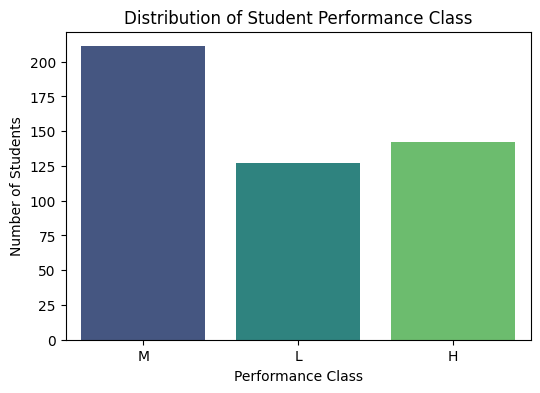

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribution of Student Performance Class')
plt.xlabel('Performance Class')
plt.ylabel('Number of Students')
plt.show()

In [16]:
cat_co = df.select_dtypes(include="object").columns
cat_co = cat_co.difference(['Class'])


In [17]:
x = df.drop("Class",axis=1)
y = df["Class"]

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# Re-run train_test_split to ensure x_train and x_test are DataFrames
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

print("Shape of x_train after re-split:", x_train.shape)
print("Shape of x_test after re-split:", x_test.shape)

Shape of x_train after re-split: (384, 16)
Shape of x_test after re-split: (96, 16)


### Performing Dummy Encoding

In [20]:
# Filter cat_co to only include columns that are currently present in x_train (not yet encoded)
# This handles cases where the cell might be run multiple times
current_cat_co_train = [col for col in cat_co if col in x_train.columns and x_train[col].dtype == 'object']
current_cat_co_test = [col for col in cat_co if col in x_test.columns and x_test[col].dtype == 'object']

if current_cat_co_train:
    x_train = pd.get_dummies(x_train, columns=current_cat_co_train, drop_first=True)
if current_cat_co_test:
    x_test = pd.get_dummies(x_test, columns=current_cat_co_test, drop_first=True)

# Align columns - this is crucial for ensuring x_test has the same columns as x_train
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

print("Shape of x_train after dummy encoding:", x_train.shape)
print("Shape of x_test after dummy encoding:", x_test.shape)

print("First 5 rows of x_train after dummy encoding:")
print(x_train.head())

Shape of x_train after dummy encoding: (384, 60)
Shape of x_test after dummy encoding: (96, 60)
First 5 rows of x_train after dummy encoding:
     raisedhands  VisITedResources  AnnouncementsView  Discussion  \
132            0                 3                 10           3   
228           73                84                 77          81   
473           85                88                 79          70   
42            10                12                  7          33   
360           20                88                 31          28   

     GradeID_G-04  GradeID_G-05  GradeID_G-06  GradeID_G-07  GradeID_G-08  \
132         False         False         False         False         False   
228         False         False         False         False         False   
473         False         False         False         False          True   
42          False         False         False         False         False   
360         False         False         False         Fals

In [21]:
from sklearn.preprocessing import StandardScaler

### Performing Feature Scaling

In [22]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

# Ensure x_test has the exact same columns as x_train before transforming
# This step was previously in c69fb3d7, but moved here for robustness
# to ensure alignment immediately before scaling.
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

x_test_scaled = scaler.transform(x_test)

# Optionally, convert back to DataFrame for easier inspection
# Use x_train.columns for x_test to ensure consistent column names and order
x_train = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)
x_test = pd.DataFrame(x_test_scaled, columns=x_train.columns, index=x_test.index)

print("Shape of x_train after scaling:", x_train.shape)
print("Shape of x_test after scaling:", x_test.shape)

print("First 5 rows of x_train after scaling:")
print(x_train.head())

Shape of x_train after scaling: (384, 60)
Shape of x_test after scaling: (96, 60)
First 5 rows of x_train after scaling:
     raisedhands  VisITedResources  AnnouncementsView  Discussion  \
132    -1.537260         -1.584846          -1.048576   -1.506316   
228     0.825654          0.861437           1.412225    1.366292   
473     1.214079          0.982241           1.485681    0.961180   
42     -1.213573         -1.313036          -1.158761   -0.401467   
360    -0.889886          0.982241          -0.277280   -0.585608   

     GradeID_G-04  GradeID_G-05  GradeID_G-06  GradeID_G-07  GradeID_G-08  \
132      -0.32654     -0.072357      -0.27501     -0.504878     -0.561310   
228      -0.32654     -0.072357      -0.27501     -0.504878     -0.561310   
473      -0.32654     -0.072357      -0.27501     -0.504878      1.781548   
42       -0.32654     -0.072357      -0.27501     -0.504878     -0.561310   
360      -0.32654     -0.072357      -0.27501     -0.504878     -0.561310   

 

In [23]:
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [26]:
score = []
train_score = []
for k in range(1,21):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(x_train,y_train)
  y_pred = knn.predict(x_test)

  accuracy = accuracy_score(y_test,y_pred)
  train = accuracy_score(y_train,knn.predict(x_train))


  score.append(accuracy)
  train_score.append(train)

In [27]:
score

[0.6979166666666666,
 0.53125,
 0.59375,
 0.5833333333333334,
 0.5833333333333334,
 0.59375,
 0.59375,
 0.5520833333333334,
 0.5625,
 0.5729166666666666,
 0.5729166666666666,
 0.59375,
 0.5833333333333334,
 0.5729166666666666,
 0.5729166666666666,
 0.6041666666666666,
 0.5833333333333334,
 0.5833333333333334,
 0.6354166666666666,
 0.5833333333333334]

In [28]:
mod = KNeighborsClassifier(n_neighbors=19)
mod.fit(x_train,y_train)
y_pred = mod.predict(x_test)

In [29]:
accuracy_score(y_test,y_pred)

0.6354166666666666

In [30]:
accuracy_score(y_train,mod.predict(x_train))

0.6588541666666666

In [31]:
import joblib
joblib.dump(mod, 'knn_model.joblib')

['knn_model.joblib']